## **Student Performance Prediction Project**

**This project analyzes and predicts student performance using demographic and academic data
After exploring the data with visualizations and preprocessing features**

**multiple regression models including Random Forest, XGBoost, LightGBM, SVR, and Neural Networks were trained to predict Math, Reading, and Writing scores**

**Multi output regression was used to predict all subjects simultaneously
 The project identified key factors influencing performance and built accurate models to support educational decision making**


# **Import**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import streamlit as st
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import export_graphviz
import graphviz
RANDOM_STATE = 42


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving StudentsPerformance.csv to StudentsPerformance (1).csv


#  **Load Dataset**


In [ ]:
df = pd.read_csv('StudentsPerformance.csv')
df.shape
print(df.head())


   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
df['gender'] = df['gender'].map({'female': 0, 'male': 1})
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,standard,none,72,72,74
1,0,group C,some college,standard,completed,69,90,88
2,0,group B,master's degree,standard,none,90,95,93
3,1,group A,associate's degree,free/reduced,none,47,57,44
4,1,group C,some college,standard,none,76,78,75


from matplotlib import pyplot as plt
_df_0['gender'].plot(kind='hist', bins=20, title='gender')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['math score'].plot(kind='hist', bins=20, title='math score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['reading score'].plot(kind='hist', bins=20, title='reading score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['writing score'].plot(kind='hist', bins=20, title='writing score')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_29['reading score'].plot(kind='hist', bins=20, title='reading score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_30.groupby('race/ethnicity').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_31.groupby('parental level of education').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_32.groupby('lunch').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_33.groupby('test preparation course').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

#  **Inspect Data**


In [ ]:
print(df.info())

print(df.describe())

print(df.isna().sum())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000

## **EDA**

---



gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


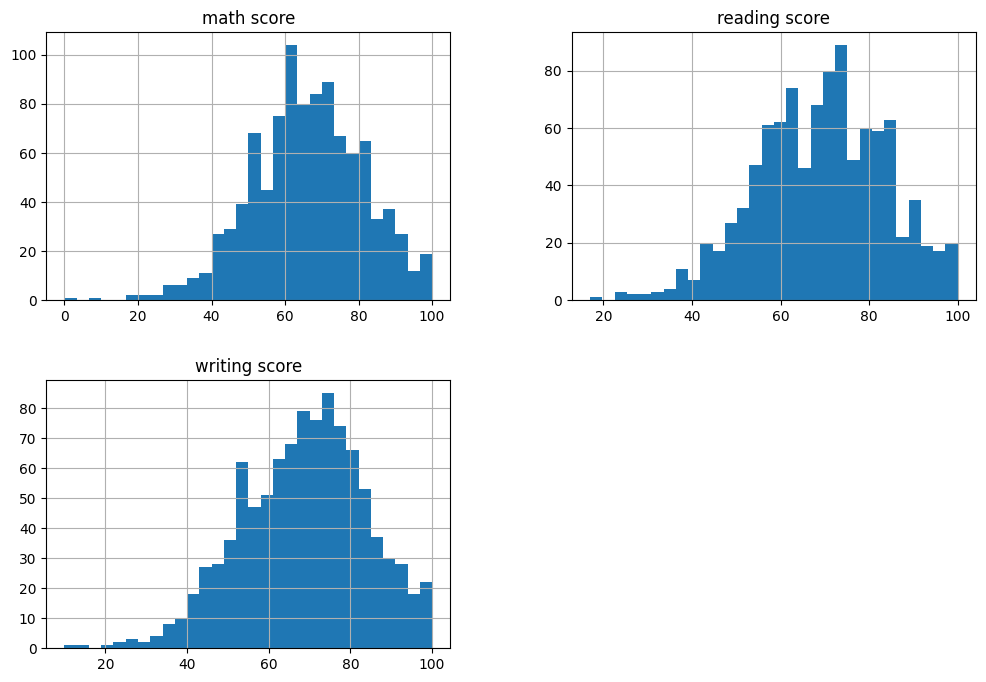

from matplotlib import pyplot as plt
_df_0['math score'].plot(kind='hist', bins=20, title='math score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['reading score'].plot(kind='hist', bins=20, title='reading score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['writing score'].plot(kind='hist', bins=20, title='writing score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_3.groupby('index').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='math score', y='reading score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_9['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_9, x='math score', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_10['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_10, x='reading score', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_11['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_11, x='writing score', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
print(df.isnull().sum())
display(df.describe())
df.hist(figsize=(12, 8), bins=30)
plt.show()





/tmp/ipython-input-3487764684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")
/tmp/ipython-input-3487764684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")
/tmp/ipython-input-3487764684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")
/tmp/ipython-input-3487764684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` fo

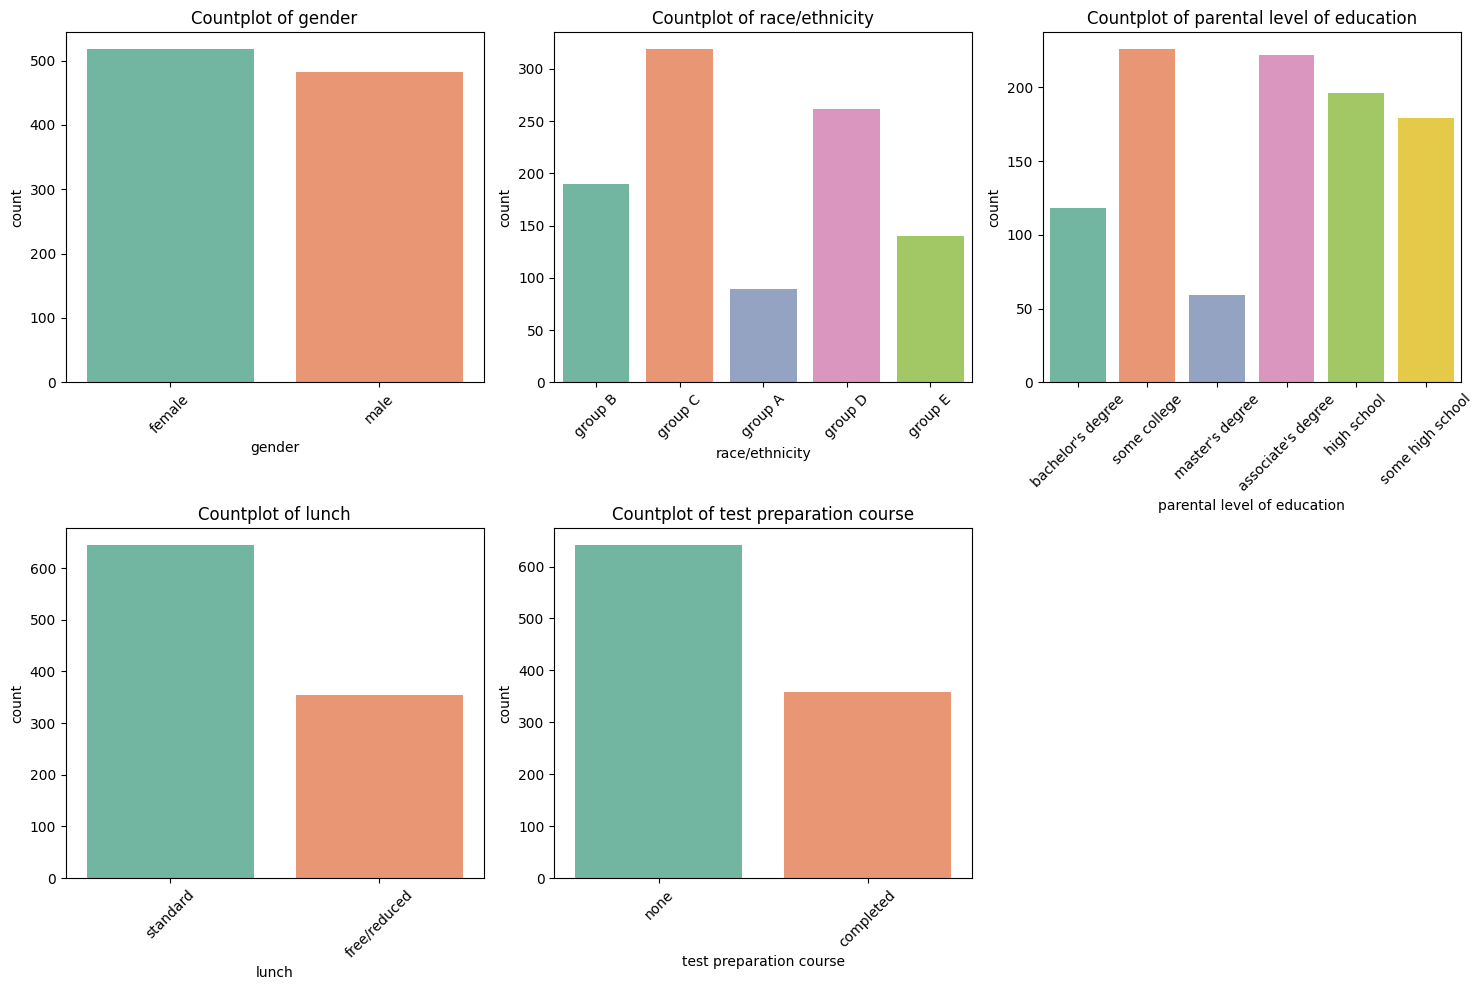

In [ ]:

categorical = df.select_dtypes(include=["object"]).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, palette="Set2")
    plt.xticks(rotation=45)
    plt.title(f"Countplot of {col}")
plt.tight_layout()
plt.show()


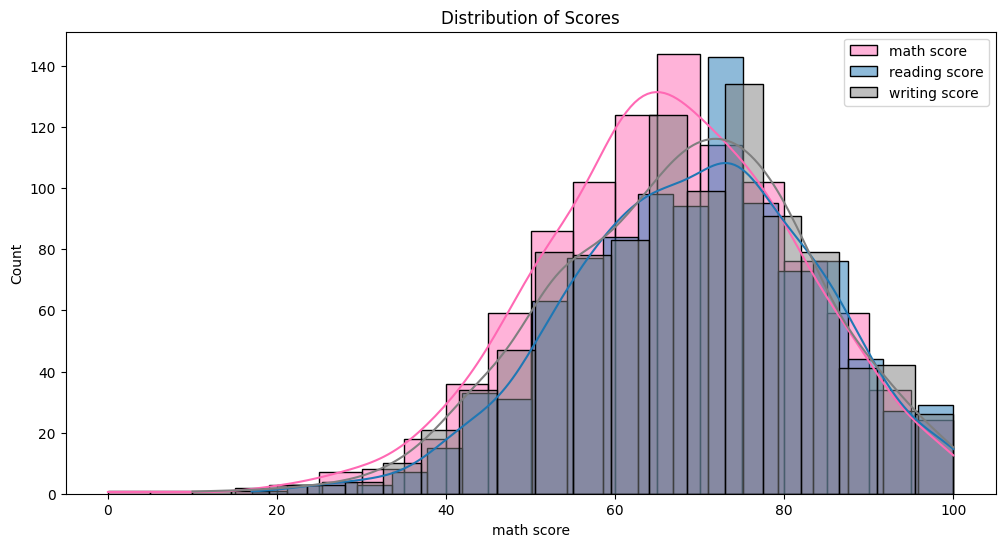

In [ ]:
plt.figure(figsize=(12,6))

colors = ["#ff69b4", "#1f77b4", "#7f7f7f"]

for col, color in zip(["math score", "reading score", "writing score"], colors):
    sns.histplot(df[col], kde=True, label=col, bins=20, color=color)

plt.legend()
plt.title("Distribution of Scores")
plt.show()


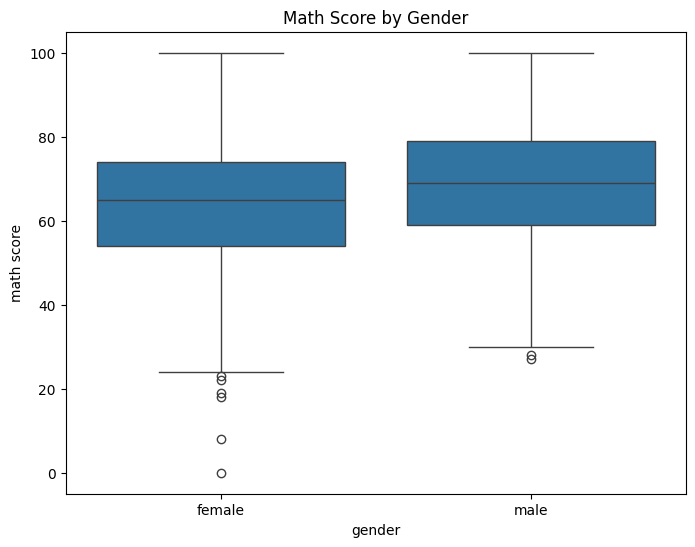

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="gender", y="math score")
plt.title("Math Score by Gender")
plt.show()

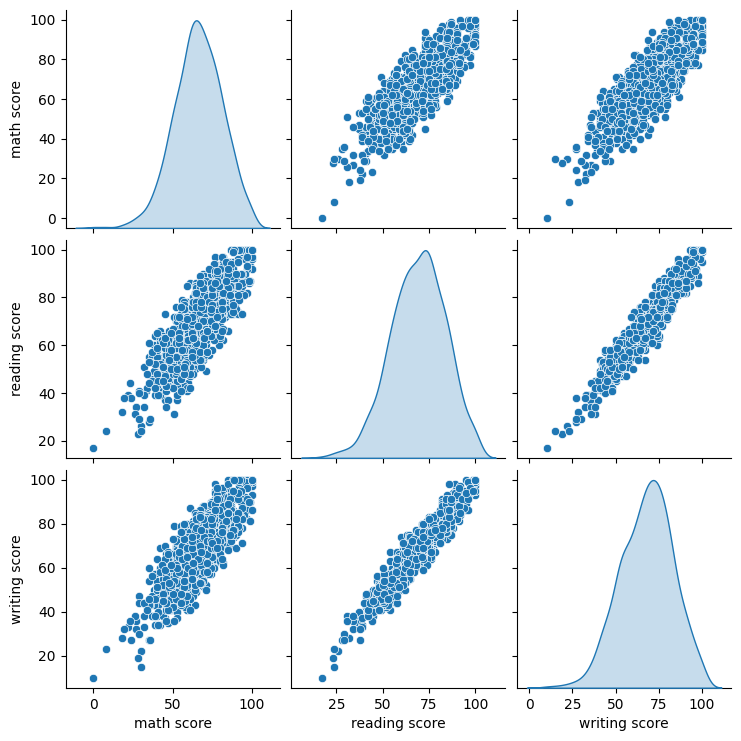

In [ ]:
sns.pairplot(df[["math score", "reading score", "writing score"]], diag_kind="kde")
plt.show()



RandomForest: MAE=11.22, RMSE=14.73, R²=0.10

XGBoost: MAE=11.52, RMSE=15.13, R²=0.05
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 17
[LightGBM] [Info] Start training from score 68.456250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1835504446.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=np.array(feats)[idx], palette="viridis")


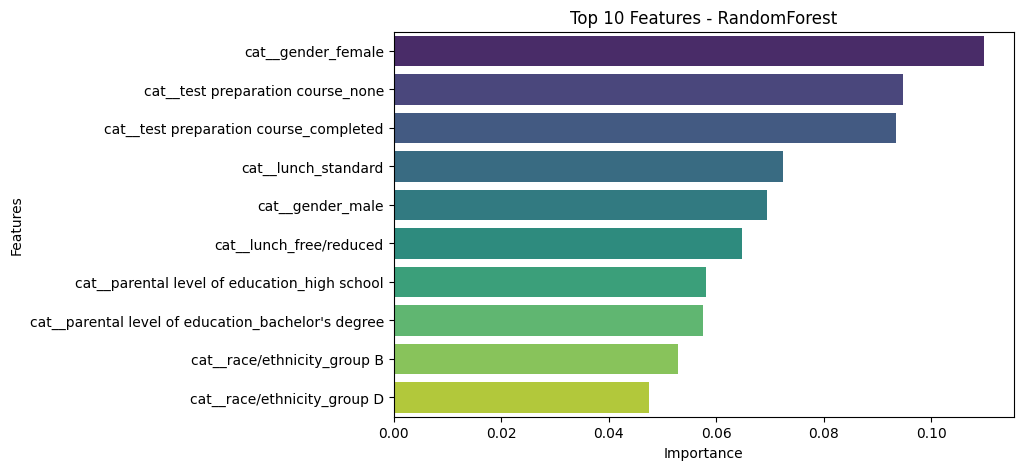

/tmp/ipython-input-1835504446.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=np.array(feats)[idx], palette="viridis")


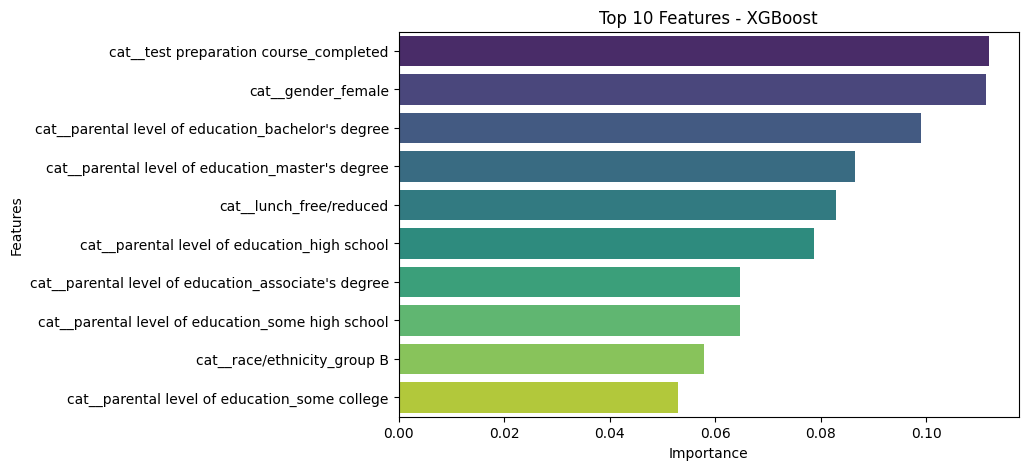

/tmp/ipython-input-1835504446.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=np.array(feats)[idx], palette="viridis")


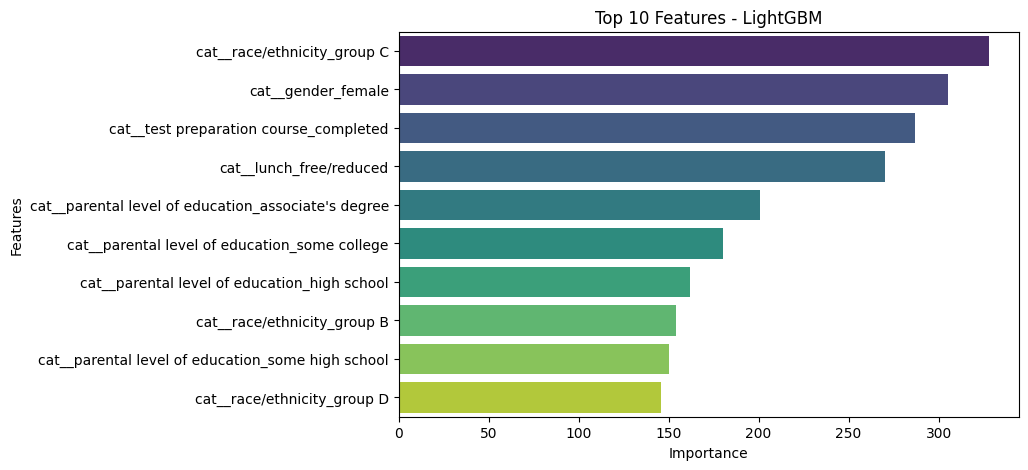

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop(columns=["math score", "reading score", "writing score"])
y = df["writing score"]

cat = X.select_dtypes(include="object").columns
num = X.select_dtypes(exclude="object").columns
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ("num", StandardScaler(), num)
])
models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=42)
}
def evaluate(name, model, Xtr, Xte, ytr, yte):
    pipe = Pipeline([("prep", preprocessor), ("model", model)]).fit(Xtr, ytr)
    y_pred = pipe.predict(Xte)
    print(f"\n{name}: MAE={mean_absolute_error(yte,y_pred):.2f}, "
          f"RMSE={np.sqrt(mean_squared_error(yte,y_pred)):.2f}, "
          f"R²={r2_score(yte,y_pred):.2f}")
    joblib.dump(pipe, f"{name}_model.pkl")
    return pipe
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
results = {n: evaluate(n, m, Xtr, Xte, ytr, yte) for n, m in models.items()}

for n, pipe in results.items():
    mdl = pipe.named_steps["model"]
    if hasattr(mdl, "feature_importances_"):
        imp = mdl.feature_importances_
        feats = pipe.named_steps["prep"].get_feature_names_out()
        idx = np.argsort(imp)[::-1][:10]

        plt.figure(figsize=(8,5))
        sns.barplot(x=imp[idx], y=np.array(feats)[idx], palette="viridis")
        plt.title(f"Top 10 Features - {n}")
        plt.xlabel("Importance")
        plt.ylabel("Features")
        plt.show()


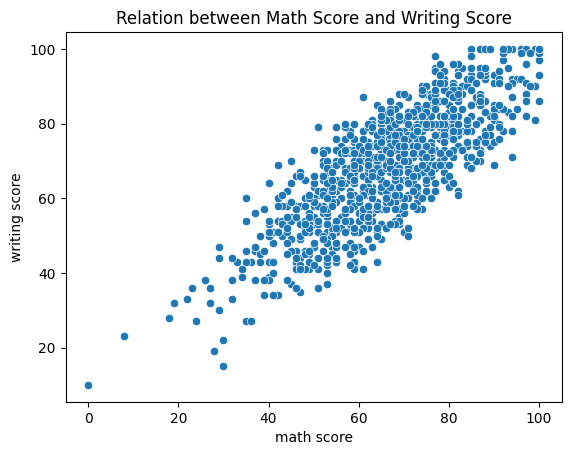

In [ ]:
sns.scatterplot(x='math score', y='writing score', data=df)
plt.title('Relation between Math Score and Writing Score')
plt.show()


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())



gender value counts:
gender
female    518
male      482
Name: count, dtype: int64

race/ethnicity value counts:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental level of education value counts:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch value counts:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test preparation course value counts:
test preparation course
none         642
completed    358
Name: count, dtype: int64


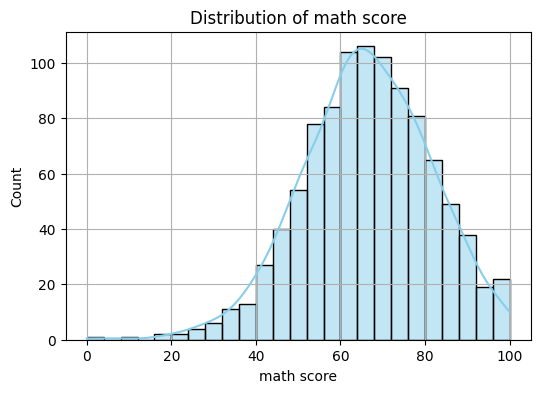

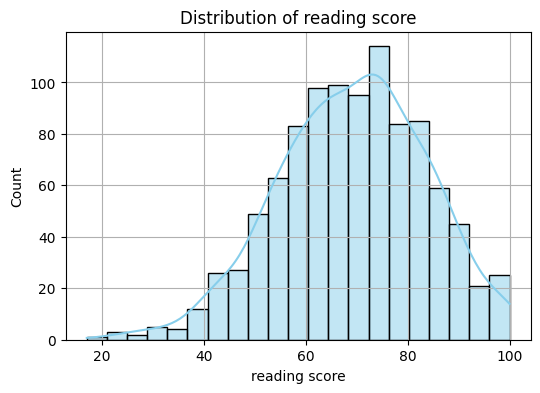

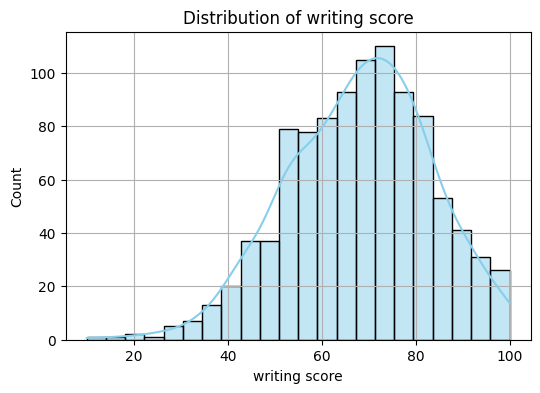

In [ ]:

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.grid(True)
    plt.show()


<Axes: xlabel='race/ethnicity', ylabel='reading score'>

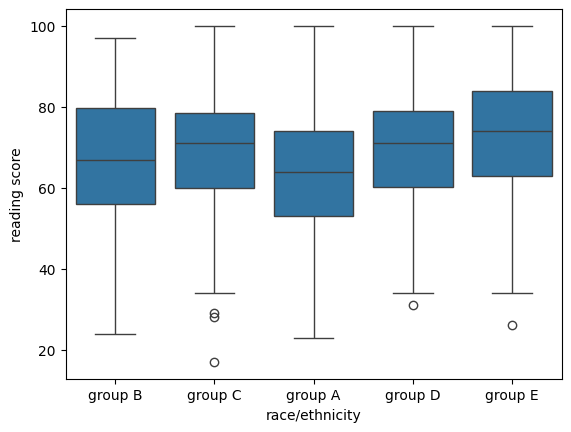

In [ ]:
sns.boxplot(data=df, x='race/ethnicity', y='reading score')





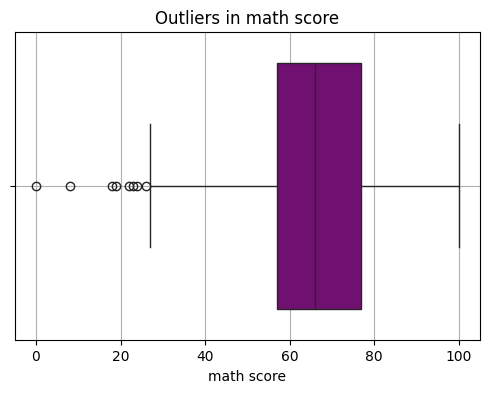

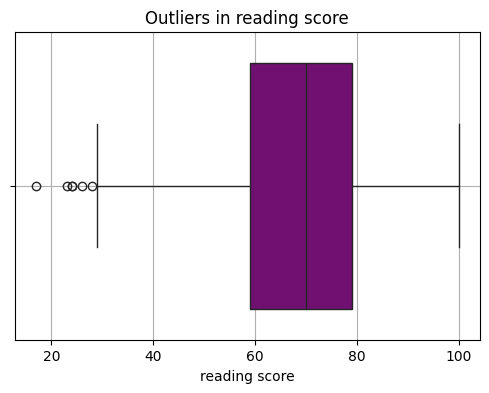

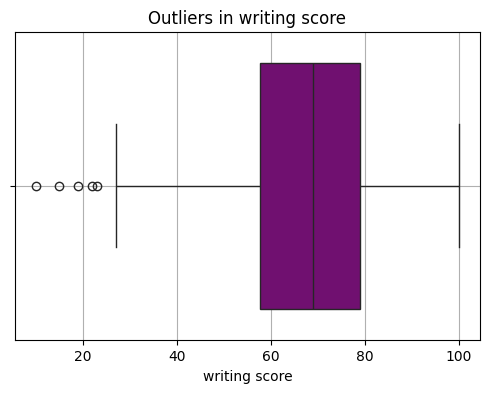

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='purple')
    plt.title(f'Outliers in {col}')
    plt.grid(True)
    plt.show()


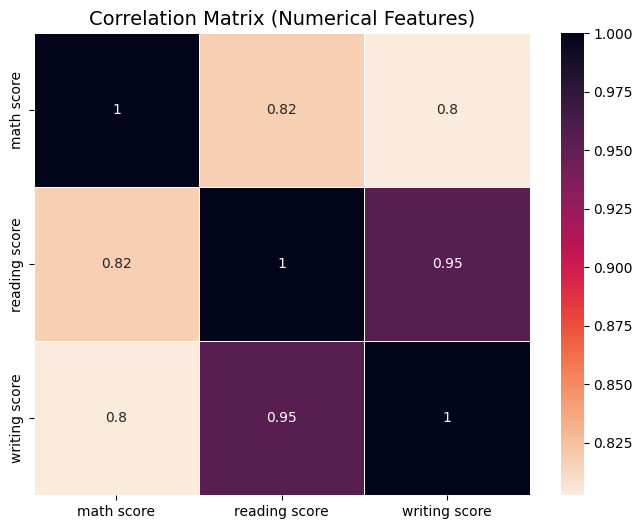

In [ ]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='rocket_r', linewidths=0.5)
plt.title('Correlation Matrix (Numerical Features)', fontsize=14)
plt.show()


#  **Features & Target**

In [ ]:
features = ["math score", "reading score"]
target = "writing score"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (800, 2)
X_test shape: (200, 2)


In [ ]:
features = ["math score", "reading score"]
target = "writing score"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print( y_pred[:5])


[85.59822883 64.17343143 72.63647191 75.96410913 82.29300047]


In [ ]:
y_pred = model.predict(X_test)

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))


Mean Absolute Error (MAE): 3.8380082149660915
R^2 Score: 0.9018108855760416


In [ ]:
features = ["math score", "reading score"]
target = "writing score"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))


Mean Absolute Error (MAE): 3.8380082149660915
R^2 Score: 0.9018108855760416


In [ ]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(10))


     Actual  Predicted
521      84  85.598229
737      73  64.173431
740      72  72.636472
660      73  75.964109
411      78  82.293000
678      78  74.581856
626      63  69.049678
513      62  59.556341
859      72  73.129211
136      41  52.782693




 ## **Train Models**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train.shape, X_test.shape


((800, 2), (200, 2))

In [ ]:
def train_and_evaluate(model, name):
    pipe = Pipeline(steps=[("preprocessor", preprocessor),("regressor", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: MAE={mae:.3f}, R2={r2:.3f}")
    return pipe, y_pred, mae, r2


In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

xgb = XGBRegressor()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

lgb = LGBMRegressor()
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)

svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

nn = MLPRegressor(max_iter=500)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'SVR', 'Neural Network'],
    'MAE': [mae_rf, mae_xgb, mae_lgb, mae_svr, mae_nn],
    'R²': [r2_rf, r2_xgb, r2_lgb, r2_svr, r2_nn]
})

print(results)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 2
[LightGBM] [Info] Start training from score 68.456250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))


Mean Absolute Error (MAE): 4.251909816017316
R^2 Score: 0.8799693746185763


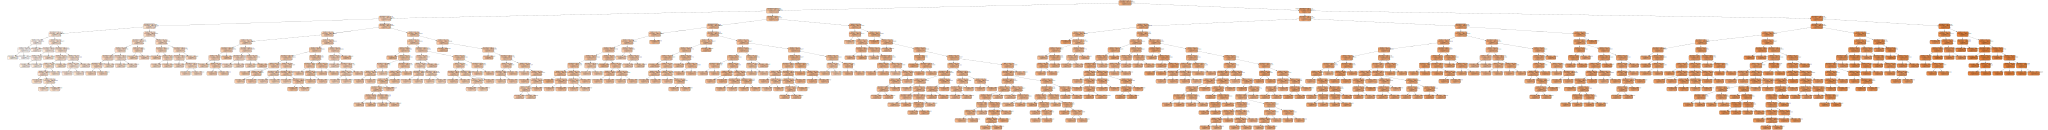

In [ ]:
estimator = model.estimators_[0]
dot_data = export_graphviz(estimator,
                           out_file=None,
                           feature_names=features,
                           filled=True,
                           rounded=True,
                           special_characters=True)

dot_data = 'digraph Tree {\nsize="120,90";\n' + '\n'.join(dot_data.split('\n')[1:])

graph = graphviz.Source(dot_data)
graph


In [ ]:

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost R^2:", r2_score(y_test, y_pred_xgb))


XGBoost MAE: 4.432031631469727
XGBoost R^2: 0.8727639317512512


In [ ]:

lgb_model = LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
print("LightGBM MAE:", mean_absolute_error(y_test, y_pred_lgb))
print("LightGBM R^2:", r2_score(y_test, y_pred_lgb))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 2
[LightGBM] [Info] Start training from score 68.456250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

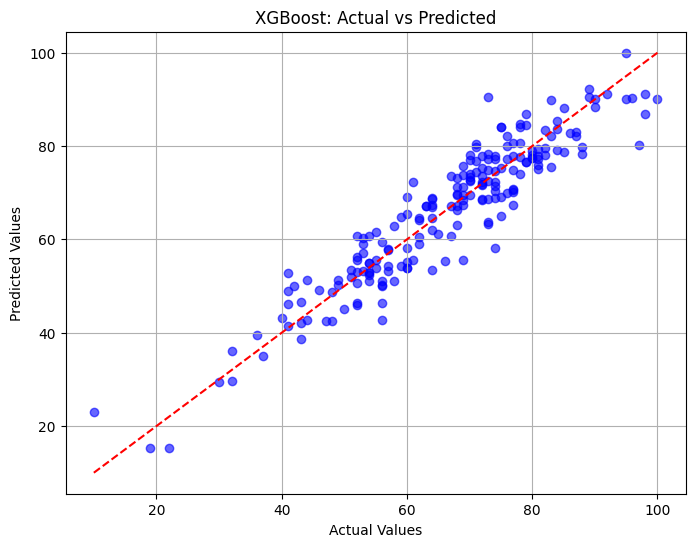

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBoost: Actual vs Predicted')
plt.grid(True)
plt.show()


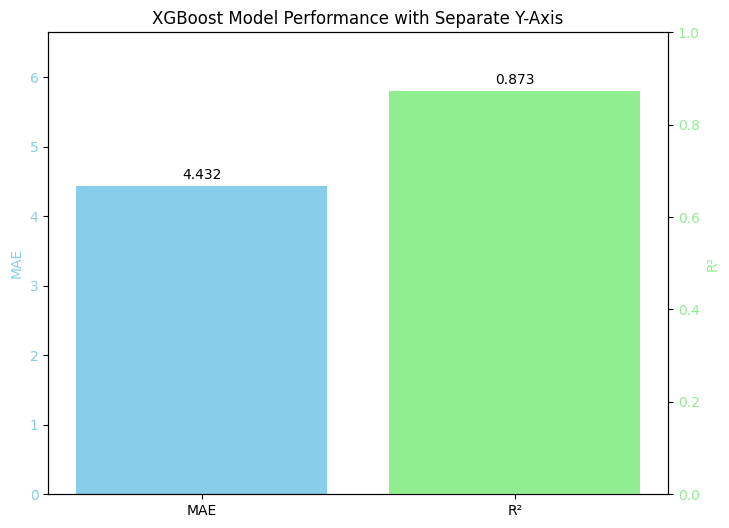

In [ ]:
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
fig, ax1 = plt.subplots(figsize=(8,6))
metrics = ['MAE']
values = [mae]
bars1 = ax1.bar(metrics, values, color='skyblue', label='MAE')
ax1.set_ylabel('MAE', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_ylim(0, mae * 1.5)
ax2 = ax1.twinx()
metrics2 = ['R²']
values2 = [r2]
bars2 = ax2.bar(metrics2, values2, color='lightgreen', label='R²')
ax2.set_ylabel('R²', color='lightgreen')
ax2.tick_params(axis='y', labelcolor='lightgreen')
ax2.set_ylim(0, 1)
def autolabel(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bars1, ax1)
autolabel(bars2, ax2)
plt.title('XGBoost Model Performance with Separate Y-Axis')
plt.show()


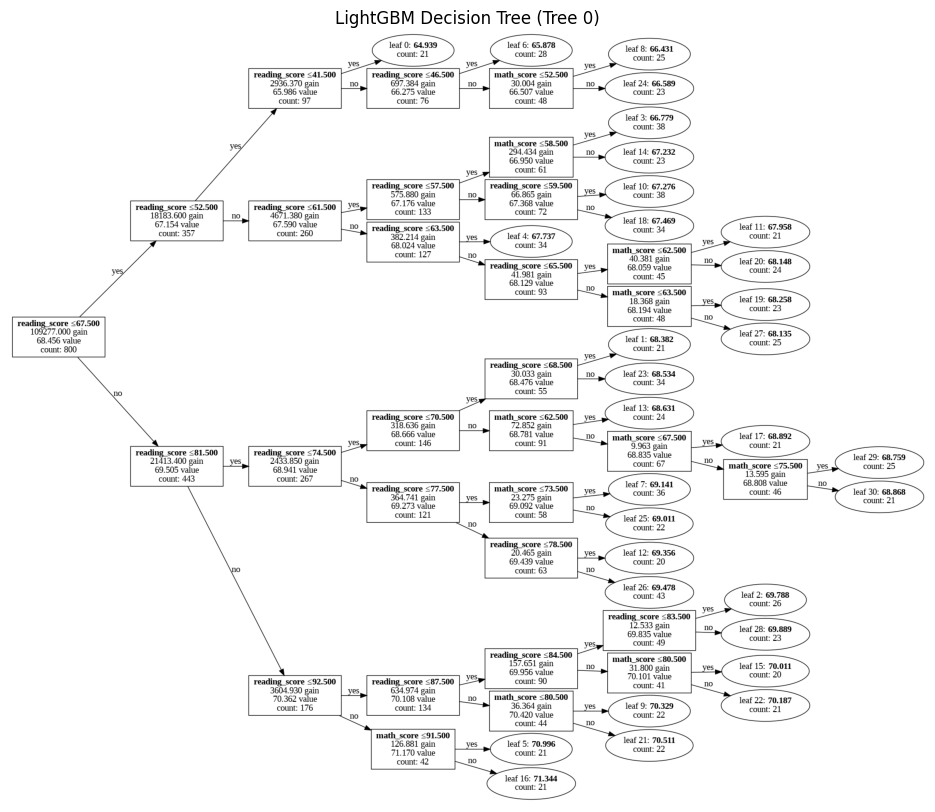

In [ ]:
ax = lgb.plot_tree(lgb_model, tree_index=0, figsize=(20, 10),
                   show_info=['split_gain', 'internal_value', 'internal_count', 'leaf_count'])

plt.title("LightGBM Decision Tree (Tree 0)")
plt.show()


In [ ]:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print("SVR MAE:", mae_svr)
print("SVR R^2:", r2_svr)


SVR MAE: 4.710009518864251
SVR R^2: 0.7769185770995763


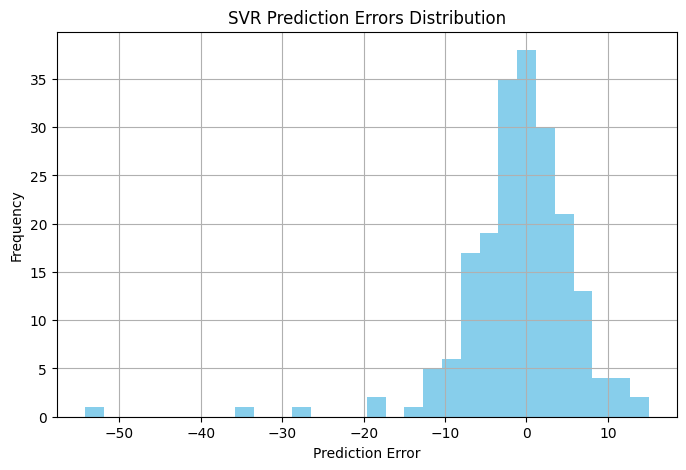

In [ ]:
errors = y_test - y_pred_svr

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30, color='skyblue')
plt.title('SVR Prediction Errors Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [ ]:
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)
print("Neural Network MAE:", mean_absolute_error(y_test, y_pred_nn))
print("Neural Network R^2:", r2_score(y_test, y_pred_nn))


Neural Network MAE: 3.8094065397587915
Neural Network R^2: 0.9031404010416212


In [ ]:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

print("SVR MAE:", mean_absolute_error(y_test, y_pred_svr))
print("SVR R^2:", r2_score(y_test, y_pred_svr))

nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

print("Neural Network MAE:", mean_absolute_error(y_test, y_pred_nn))
print("Neural Network R^2:", r2_score(y_test, y_pred_nn))


SVR MAE: 4.710009518864251
SVR R^2: 0.7769185770995763
Neural Network MAE: 3.8094065397587915
Neural Network R^2: 0.9031404010416212


In [ ]:
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)


MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)

#  **Residuals**

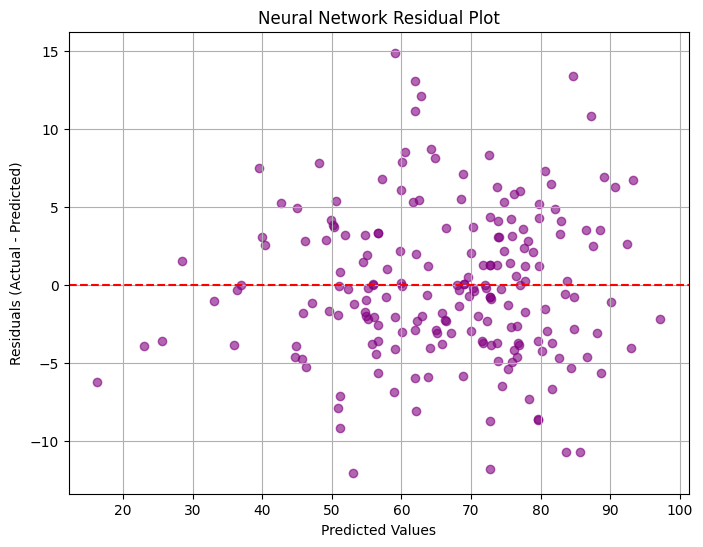

In [ ]:
residuals = y_test - y_pred_nn

plt.figure(figsize=(8,6))
plt.scatter(y_pred_nn, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Neural Network Residual Plot')
plt.grid(True)
plt.show()


In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


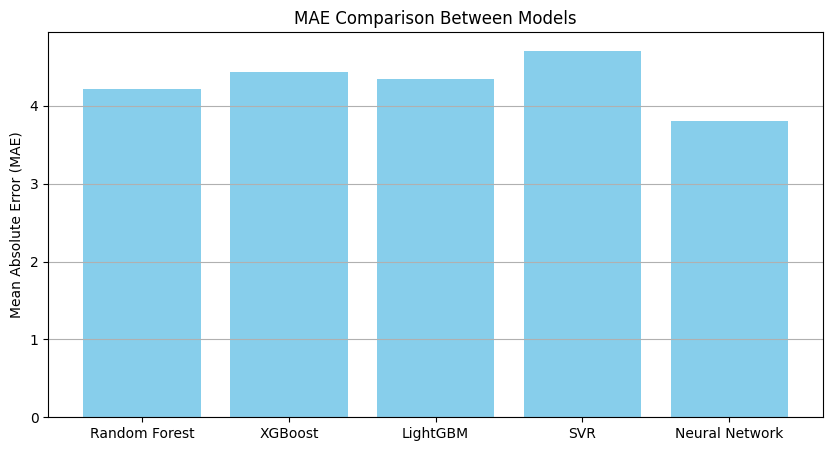

In [ ]:
models = ['Random Forest', 'XGBoost', 'LightGBM', 'SVR', 'Neural Network']

mae_scores = [
    mean_absolute_error(y_test, y_pred_rf),
    mean_absolute_error(y_test, y_pred_xgb),
    mean_absolute_error(y_test, y_pred_lgb),
    mean_absolute_error(y_test, y_pred_svr),
    mean_absolute_error(y_test, y_pred_nn)
]

r2_scores = [
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xgb),
    r2_score(y_test, y_pred_lgb),
    r2_score(y_test, y_pred_svr),
    r2_score(y_test, y_pred_nn)
]

plt.figure(figsize=(10,5))
plt.bar(models, mae_scores, color='skyblue')
plt.title('MAE Comparison Between Models')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid(axis='y')
plt.show()



### **Multi output Regression**


In [ ]:
X_multi = df.drop(columns=["math score", "reading score", "writing score"])

y_multi = df[["math score", "reading score", "writing score"]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

multi_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MultiOutputRegressor(RandomForestRegressor(random_state=42)))
])

multi_pipe.fit(X_train_m, y_train_m)

y_pred_m = multi_pipe.predict(X_test_m)

from sklearn.metrics import r2_score, mean_absolute_error

print("\n=== Multi-output Regression Results ===")
for i, subject in enumerate(["math score", "reading score", "writing score"]):
    r2 = r2_score(y_test_m.iloc[:, i], y_pred_m[:, i])
    mae = mean_absolute_error(y_test_m.iloc[:, i], y_pred_m[:, i])
    print(f"{subject}: R² = {r2:.2f}, MAE = {mae:.2f}")

joblib.dump(multi_pipe, "multioutput_model.pkl")



=== Multi-output Regression Results ===
math score: R² = -0.01, MAE = 12.32
reading score: R² = -0.02, MAE = 11.82
writing score: R² = 0.10, MAE = 11.22


['multioutput_model.pkl']

## **Deployment (Streamlit)**

In [ ]:
joblib.dump(rf_model, "rf_model.pkl")

files.download("rf_model.pkl")
uploaded = files.upload()

model = joblib.load("rf_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#  **GridSearchCV**

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)

print( grid.best_params_)
print( -grid.best_score_)


{'max_depth': 5, 'n_estimators': 200}
3.760459499476387


#  **Save Model**


In [ ]:
features = ['math score', 'reading score']
target = 'writing score'
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
joblib.dump(lr_model, "linear_model.pkl")

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

joblib.dump(rf_model, "rf_model.pkl")
xgb_model = XGBRegressor(random_state=42, n_estimators=100)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)
joblib.dump(xgb_model, "xgb_model.pkl")
nn_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)
nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_r2 = r2_score(y_test, y_pred_nn)
joblib.dump(nn_model, "nn_model.pkl")


['nn_model.pkl']